# **Corelation In Python**


# Correlation

## Definition

**Correlation** is a statistical method used to measure the **strength and direction of the relationship between two variables**.

It tells us how two variables change in relation to each other.

---

## Types of Correlation

### 1. Positive Correlation

When one variable increases, the other variable also tends to increase.

**Example:**  
Study Hours ↑ → Exam Marks ↑

### 2. Negative Correlation

When one variable increases, the other variable tends to decrease.

**Example:**  
Screen Time ↑ → Study Time ↓

### 3. No Correlation

When there is no clear relationship between two variables.

---

# Types of Correlation Tests

## 1. Pearson Correlation Test

The **Pearson correlation test** measures the **linear relationship** between two continuous numerical variables.

### Formula

$$
r = \frac{\sum (X-\bar{X})(Y-\bar{Y})}
{\sqrt{\sum (X-\bar{X})^2 \sum (Y-\bar{Y})^2}}
$$

Where:

- **r** = Pearson correlation coefficient
- **X** = Values of the first variable
- **Y** = Values of the second variable
- **X̄** = Mean of X
- **Ȳ** = Mean of Y

### Range of Pearson Correlation

$$
-1 \leq r \leq +1
$$

- **r = +1** → Perfect Positive Correlation
- **r = -1** → Perfect Negative Correlation
- **r = 0** → No Linear Correlation

### Example

**Study Hours** and **Exam Marks** can be analyzed using Pearson correlation.

If:

$$
r = 0.85
$$

This indicates a **strong positive correlation** between study hours and exam marks.

---

## 2. Spearman Rank Correlation Test

The **Spearman correlation test** measures the relationship between two variables based on their **ranks**.

It is useful when the data is not normally distributed or when the relationship is **monotonic**.

### Formula

$$
\rho = 1 - \frac{6\sum d^2}{n(n^2-1)}
$$

Where:

- **ρ** = Spearman rank correlation coefficient
- **d** = Difference between the two ranks
- **n** = Number of observations

---

## 3. Kendall's Tau Correlation Test

**Kendall's Tau** measures the strength and direction of association between two **ranked or ordinal variables**.

It is useful for ordinal data and smaller datasets.

---

## Important Note

**Correlation does not necessarily mean causation.**

A correlation between two variables does not prove that one variable causes the other.

In [5]:
import pandas as pd
import numpy as np
#create a function
def pearson(x,y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    std_x = np.std(x)
    std_y = np.std(y)
    n = len(x)
    return sum((x-x_mean)*(y-y_mean))/(n*std_x*std_y)
    #example dataset
x=np.array([1,2,3,4,5])
y=np.array([2,4,5,4,5])
#print the result
print(f'Pearson Corelation:{pearson(x,y)}')
# print with condition statement
if pearson(x, y) > 0.6:
    print("Highly Positive Correlation")
elif pearson(x, y) > 0:
    print("Positive Correlation")
elif pearson(x, y) < -0.6:
    print("Highly Negative Correlation")
elif pearson(x, y) < 0:
    print("Negative Correlation")
else:
    print("No Correlation")

Pearson Corelation:0.7745966692414834
Highly Positive Correlation


# **Spearman Corelation Co efficient**

In [10]:
import pandas as pd
import numpy as np

# Create a function for Spearman Correlation
def spearman(x, y):

    # Convert values into ranks
    rank_x = pd.Series(x).rank().to_numpy()
    rank_y = pd.Series(y).rank().to_numpy()

    # Calculate mean of ranks
    x_mean = np.mean(rank_x)
    y_mean = np.mean(rank_y)

    # Calculate standard deviation
    std_x = np.std(rank_x)
    std_y = np.std(rank_y)

    # Number of observations
    n = len(rank_x)

    # Spearman correlation
    return sum((rank_x - x_mean) * (rank_y - y_mean)) / (n * std_x * std_y)


# Example dataset
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

# Print the result
result = spearman(x, y)

print(f'Spearman Correlation: {result:.4f}')


# Print with condition statement
if result > 0.6:
    print("Highly Positive Correlation")

elif result > 0:
    print("Positive Correlation")

elif result < -0.6:
    print("Highly Negative Correlation")

elif result < 0:
    print("Negative Correlation")

else:
    print("No Correlation")

Spearman Correlation: 0.7379
Highly Positive Correlation


In [18]:
df = pd.DataFrame({'x':x,'y':y})
df.head()
p = df.corr(method ='pearson')
s = df.corr(method = 'spearman')
k = df.corr(method = 'kendall')

#print the result
print(p)
print('---------------------------------------------------')
print(s)
print('---------------------------------------------------')
print(k)

          x         y
x  1.000000  0.774597
y  0.774597  1.000000
---------------------------------------------------
          x         y
x  1.000000  0.737865
y  0.737865  1.000000
---------------------------------------------------
         x        y
x  1.00000  0.67082
y  0.67082  1.00000


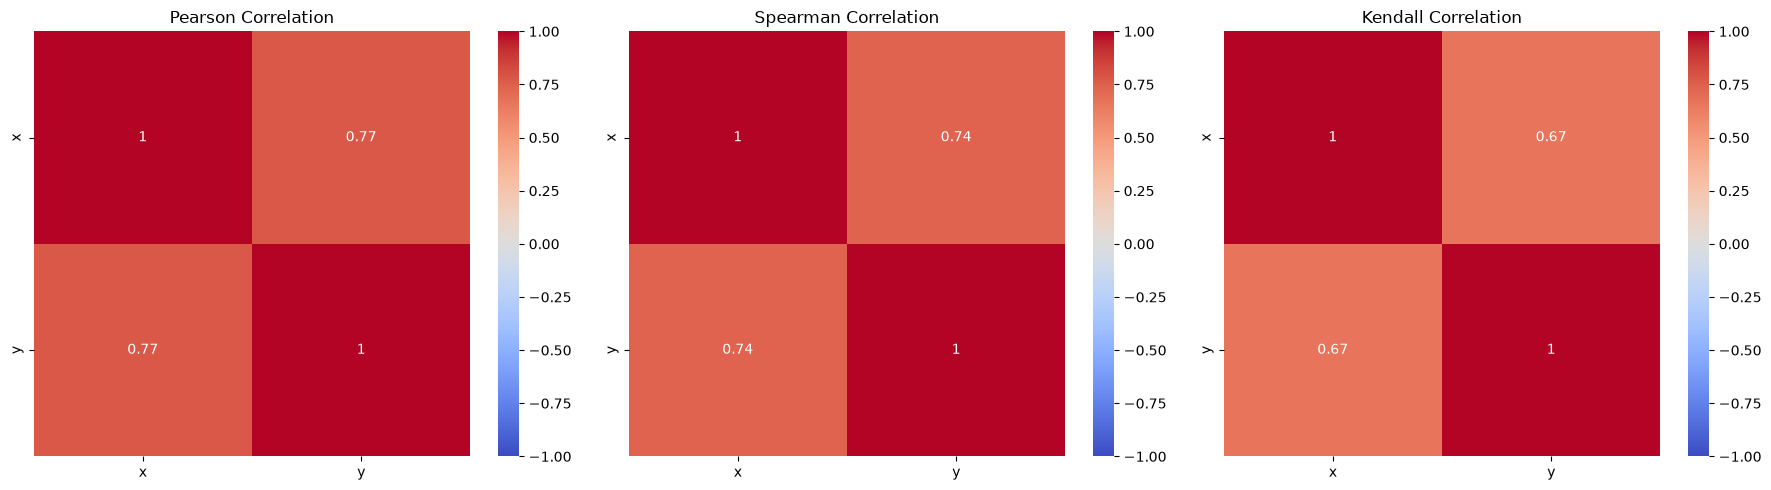

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(p, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation')

sns.heatmap(s, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation')

sns.heatmap(k, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Kendall Correlation')

plt.tight_layout()
plt.show()